# Classical line vectorisation baseline — Hough, merge, and snap

This notebook replaces the neural network with a classical vectorisation pipeline:

```text
input raster → Hough line detector → angle snap → collinear merge → intersection snap → vector/raster output
```

It is designed for the same 64×64 synthetic black-line images used in the previous notebooks.


In [16]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

try:
    import cv2
    print("OpenCV version:", cv2.__version__)
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "OpenCV is required for this notebook. Install it with: pip install opencv-python"
    ) from error


OpenCV version: 5.0.0


## Settings

In [17]:
IMG_SIZE = 64

N_TEST = 500

MAX_LINES = 5
MIN_LINES = 1
VALUES_PER_LINE = 5

LINE_WIDTH = 1

# These weights only control the synthetic test data.
# They make horizontal, vertical, and common drawing angles appear more often.
ANGLE_WEIGHT_HORIZONTAL = 60
ANGLE_WEIGHT_VERTICAL = 60
ANGLE_WEIGHT_45 = 25
ANGLE_WEIGHT_60 = 15
ANGLE_WEIGHT_30 = 10
ANGLE_WEIGHT_5 = 7
ANGLE_WEIGHT_OTHER = 3

np.random.seed(42)


## Synthetic data generator

The labels are still endpoint labels so that the detected vectors can be compared with the known generated lines if needed.


In [18]:
def build_angle_groups():
    all_angles = set(range(0, 180))

    horizontal = {0}
    vertical = {90}

    angle_45 = {
        angle for angle in all_angles
        if angle % 45 == 0
        and angle not in horizontal
        and angle not in vertical
    }

    angle_60 = {
        angle for angle in all_angles
        if angle % 60 == 0
        and angle not in horizontal
        and angle not in vertical
        and angle not in angle_45
    }

    angle_30 = {
        angle for angle in all_angles
        if angle % 30 == 0
        and angle not in horizontal
        and angle not in vertical
        and angle not in angle_45
        and angle not in angle_60
    }

    angle_5 = {
        angle for angle in all_angles
        if angle % 5 == 0
        and angle not in horizontal
        and angle not in vertical
        and angle not in angle_45
        and angle not in angle_60
        and angle not in angle_30
    }

    used_angles = horizontal | vertical | angle_45 | angle_60 | angle_30 | angle_5
    angle_other = all_angles - used_angles

    return {
        "horizontal": sorted(horizontal),
        "vertical": sorted(vertical),
        "45": sorted(angle_45),
        "60": sorted(angle_60),
        "30": sorted(angle_30),
        "5": sorted(angle_5),
        "other": sorted(angle_other),
    }


ANGLE_GROUPS = build_angle_groups()


def choose_weighted_angle():
    group_names = [
        "horizontal",
        "vertical",
        "45",
        "60",
        "30",
        "5",
        "other"
    ]

    group_weights = np.array([
        ANGLE_WEIGHT_HORIZONTAL,
        ANGLE_WEIGHT_VERTICAL,
        ANGLE_WEIGHT_45,
        ANGLE_WEIGHT_60,
        ANGLE_WEIGHT_30,
        ANGLE_WEIGHT_5,
        ANGLE_WEIGHT_OTHER
    ], dtype="float32")

    group_probabilities = group_weights / np.sum(group_weights)

    selected_group = np.random.choice(group_names, p=group_probabilities)
    selected_angle = np.random.choice(ANGLE_GROUPS[selected_group])

    return int(selected_angle)


def create_line_image(img_size=64, min_length=12, min_lines=1, max_lines=5):
    def random_line():
        while True:
            angle_degrees = choose_weighted_angle()
            angle_radians = np.deg2rad(angle_degrees)

            cos_a = np.cos(angle_radians)
            sin_a = np.sin(angle_radians)

            max_length_x = np.inf if abs(cos_a) < 1e-8 else (img_size - 1) / abs(cos_a)
            max_length_y = np.inf if abs(sin_a) < 1e-8 else (img_size - 1) / abs(sin_a)
            max_possible_length = min(max_length_x, max_length_y)

            if max_possible_length < min_length:
                continue

            line_length = np.random.uniform(min_length, max_possible_length)

            dx = cos_a * line_length / 2
            dy = sin_a * line_length / 2

            cx_min = abs(dx)
            cx_max = (img_size - 1) - abs(dx)
            cy_min = abs(dy)
            cy_max = (img_size - 1) - abs(dy)

            if cx_min > cx_max or cy_min > cy_max:
                continue

            cx = np.random.uniform(cx_min, cx_max)
            cy = np.random.uniform(cy_min, cy_max)

            x1 = int(round(cx - dx))
            y1 = int(round(cy - dy))
            x2 = int(round(cx + dx))
            y2 = int(round(cy + dy))

            if not (0 <= x1 < img_size and 0 <= y1 < img_size):
                continue
            if not (0 <= x2 < img_size and 0 <= y2 < img_size):
                continue

            actual_length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

            if actual_length >= min_length:
                return x1, y1, x2, y2, angle_degrees

    number_of_lines = np.random.randint(min_lines, max_lines + 1)
    lines = [random_line() for _ in range(number_of_lines)]

    lines = sorted(
        lines,
        key=lambda line: (
            (line[0] + line[2]) / 2,
            (line[1] + line[3]) / 2
        )
    )

    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    label_values = []

    for x1, y1, x2, y2, angle_degrees in lines:
        draw.line((x1, y1, x2, y2), fill=0, width=LINE_WIDTH)

        label_values.extend([
            x1 / (img_size - 1),
            y1 / (img_size - 1),
            x2 / (img_size - 1),
            y2 / (img_size - 1),
            1.0
        ])

    while len(label_values) < max_lines * VALUES_PER_LINE:
        label_values.extend([0.0, 0.0, 0.0, 0.0, 0.0])

    image_array = np.array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=-1)

    label = np.array(label_values, dtype="float32")

    return image_array, label


def create_dataset(n_samples, img_size=64):
    images = []
    labels = []

    for _ in range(n_samples):
        image, label = create_line_image(
            img_size=img_size,
            min_lines=MIN_LINES,
            max_lines=MAX_LINES
        )

        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)


X_test: (500, 64, 64, 1)
y_test: (500, 25)


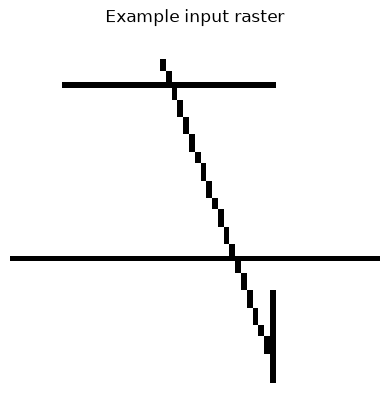

In [19]:
X_test, y_test = create_dataset(N_TEST, IMG_SIZE)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

plt.imshow(X_test[0].squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
plt.title("Example input raster")
plt.axis("off")
plt.show()


## General line helpers

In [20]:
def line_length(line):
    return float(np.hypot(line["x2"] - line["x1"], line["y2"] - line["y1"]))


def line_angle_degrees(line):
    angle = np.degrees(np.arctan2(line["y2"] - line["y1"], line["x2"] - line["x1"]))
    return float(angle % 180)


def angle_difference_degrees(a, b):
    diff = abs((a - b) % 180)
    return min(diff, 180 - diff)


def canonicalise_line(line):
    x1, y1, x2, y2 = line["x1"], line["y1"], line["x2"], line["y2"]

    if (x2 < x1) or (x2 == x1 and y2 < y1):
        x1, y1, x2, y2 = x2, y2, x1, y1

    return {
        "x1": int(round(x1)),
        "y1": int(round(y1)),
        "x2": int(round(x2)),
        "y2": int(round(y2)),
        "angle": int(round(line_angle_degrees({"x1": x1, "y1": y1, "x2": x2, "y2": y2}))) % 180,
        "length": float(np.hypot(x2 - x1, y2 - y1))
    }


def decode_endpoint_vector(vector, img_size=64, confidence_threshold=0.5):
    vector = vector.reshape(MAX_LINES, VALUES_PER_LINE)
    decoded_lines = []

    for line in vector:
        x1, y1, x2, y2, confidence = line

        if confidence >= confidence_threshold:
            output_line = canonicalise_line({
                "x1": x1 * (img_size - 1),
                "y1": y1 * (img_size - 1),
                "x2": x2 * (img_size - 1),
                "y2": y2 * (img_size - 1),
            })
            output_line["confidence"] = float(confidence)
            decoded_lines.append(output_line)

    return decoded_lines


def rasterise_lines(lines, img_size=64, line_width=1):
    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    for line in lines:
        draw.line(
            (line["x1"], line["y1"], line["x2"], line["y2"]),
            fill=0,
            width=line_width
        )

    return np.array(image).astype("float32") / 255.0


def plot_lines_on_image(image, lines, title="Lines", figsize=(5, 5), show_line_numbers=True):
    plt.figure(figsize=figsize)
    plt.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")

    for index, line in enumerate(lines):
        plt.plot([line["x1"], line["x2"]], [line["y1"], line["y2"]], linewidth=2)

        if show_line_numbers:
            cx = (line["x1"] + line["x2"]) / 2
            cy = (line["y1"] + line["y2"]) / 2
            plt.text(cx, cy, str(index + 1), fontsize=9)

    plt.title(title)
    plt.xlim(-1, image.shape[1])
    plt.ylim(image.shape[0], -1)
    plt.axis("off")
    plt.show()


## Hough detector

`cv2.HoughLinesP` returns line segments as endpoints.

Tune these three parameters first:

- `threshold`: lower means more lines are detected.
- `min_line_length`: lower means shorter fragments are kept.
- `max_line_gap`: higher means broken fragments are joined.


In [21]:
def prepare_hough_binary(image):
    img = image.squeeze()

    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    # The input uses black lines on a white background.
    # Hough expects non-zero pixels for the features, so invert the image.
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

    return binary


def detect_lines_hough(image, threshold=12, min_line_length=8, max_line_gap=2):
    binary = prepare_hough_binary(image)

    detected = cv2.HoughLinesP(
        binary,
        rho=1,
        theta=np.pi / 180,
        threshold=int(threshold),
        minLineLength=int(min_line_length),
        maxLineGap=int(max_line_gap)
    )

    if detected is None:
        return []

    lines = []

    for raw_line in detected:
        x1, y1, x2, y2 = raw_line[0]
        line = canonicalise_line({"x1": x1, "y1": y1, "x2": x2, "y2": y2})

        if line["length"] >= min_line_length:
            lines.append(line)

    lines = sorted(lines, key=lambda line: line["length"], reverse=True)
    return lines


## Angle snapping

In [22]:
def snap_line_to_angle_step(line, img_size=64, angle_step=1):
    x1 = float(line["x1"])
    y1 = float(line["y1"])
    x2 = float(line["x2"])
    y2 = float(line["y2"])

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    length = np.hypot(x2 - x1, y2 - y1)

    if length < 1e-8:
        return canonicalise_line(line)

    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
    snapped_angle = round(angle / angle_step) * angle_step
    snapped_angle = snapped_angle % 180

    angle_radians = np.deg2rad(snapped_angle)

    dx = np.cos(angle_radians) * length / 2
    dy = np.sin(angle_radians) * length / 2

    snapped_line = {
        "x1": np.clip(cx - dx, 0, img_size - 1),
        "y1": np.clip(cy - dy, 0, img_size - 1),
        "x2": np.clip(cx + dx, 0, img_size - 1),
        "y2": np.clip(cy + dy, 0, img_size - 1),
    }

    snapped_line = canonicalise_line(snapped_line)
    snapped_line["angle"] = int(round(snapped_angle)) % 180
    return snapped_line


def snap_lines_to_angle_step(lines, img_size=64, angle_step=1):
    return [snap_line_to_angle_step(line, img_size=img_size, angle_step=angle_step) for line in lines]


## Merge near-collinear fragments

Hough often returns several pieces for one real line. This function merges lines that are:

- similar in angle,
- close to the same infinite line,
- overlapping or separated by a small gap.


In [23]:
def _line_frame(line, angle_degrees=None):
    if angle_degrees is None:
        angle_degrees = line_angle_degrees(line)

    theta = np.deg2rad(angle_degrees)
    u = np.array([np.cos(theta), np.sin(theta)], dtype="float64")
    n = np.array([-np.sin(theta), np.cos(theta)], dtype="float64")

    p1 = np.array([line["x1"], line["y1"]], dtype="float64")
    p2 = np.array([line["x2"], line["y2"]], dtype="float64")
    centre = (p1 + p2) / 2

    s1 = float(np.dot(p1, u))
    s2 = float(np.dot(p2, u))
    r = float(np.dot(centre, n))

    return u, n, min(s1, s2), max(s1, s2), r


def _interval_gap(a_min, a_max, b_min, b_max):
    if a_max < b_min:
        return b_min - a_max
    if b_max < a_min:
        return a_min - b_max
    return 0.0


def _merge_one_cluster(cluster, img_size=64):
    angles = np.array([line_angle_degrees(line) for line in cluster], dtype="float64")

    # Use the first angle as the frame. The cluster has already passed the angle tolerance test.
    angle = float(angles[0])
    u, n, _, _, _ = _line_frame(cluster[0], angle_degrees=angle)

    projections = []
    offsets = []

    for line in cluster:
        p1 = np.array([line["x1"], line["y1"]], dtype="float64")
        p2 = np.array([line["x2"], line["y2"]], dtype="float64")

        projections.extend([float(np.dot(p1, u)), float(np.dot(p2, u))])
        offsets.extend([float(np.dot(p1, n)), float(np.dot(p2, n))])

    s_min = min(projections)
    s_max = max(projections)
    r_mean = float(np.mean(offsets))

    p_start = u * s_min + n * r_mean
    p_end = u * s_max + n * r_mean

    merged = {
        "x1": np.clip(p_start[0], 0, img_size - 1),
        "y1": np.clip(p_start[1], 0, img_size - 1),
        "x2": np.clip(p_end[0], 0, img_size - 1),
        "y2": np.clip(p_end[1], 0, img_size - 1),
    }

    return canonicalise_line(merged)


def merge_collinear_segments(
    lines,
    img_size=64,
    angle_tolerance=3.0,
    distance_tolerance=1.5,
    max_gap=5.0,
    max_iterations=5
):
    if len(lines) <= 1:
        return lines

    working_lines = [canonicalise_line(line) for line in lines]

    for _ in range(max_iterations):
        used = np.zeros(len(working_lines), dtype=bool)
        merged_lines = []
        changed = False

        working_lines = sorted(working_lines, key=lambda line: line["length"], reverse=True)

        for i, base_line in enumerate(working_lines):
            if used[i]:
                continue

            base_angle = line_angle_degrees(base_line)
            base_u, base_n, base_min, base_max, base_r = _line_frame(base_line, angle_degrees=base_angle)

            cluster = [base_line]
            used[i] = True

            for j in range(i + 1, len(working_lines)):
                candidate = working_lines[j]

                if used[j]:
                    continue

                candidate_angle = line_angle_degrees(candidate)
                angle_diff = angle_difference_degrees(base_angle, candidate_angle)

                if angle_diff > angle_tolerance:
                    continue

                p1 = np.array([candidate["x1"], candidate["y1"]], dtype="float64")
                p2 = np.array([candidate["x2"], candidate["y2"]], dtype="float64")
                centre = (p1 + p2) / 2

                candidate_r = float(np.dot(centre, base_n))
                perpendicular_distance = abs(candidate_r - base_r)

                if perpendicular_distance > distance_tolerance:
                    continue

                s1 = float(np.dot(p1, base_u))
                s2 = float(np.dot(p2, base_u))
                candidate_min = min(s1, s2)
                candidate_max = max(s1, s2)

                gap = _interval_gap(base_min, base_max, candidate_min, candidate_max)

                if gap > max_gap:
                    continue

                cluster.append(candidate)
                used[j] = True
                changed = True

            merged_lines.append(_merge_one_cluster(cluster, img_size=img_size))

        working_lines = merged_lines

        if not changed:
            break

    return sorted(working_lines, key=lambda line: line["length"], reverse=True)


## Intersection endpoint snapping

This is useful for corners and T-junctions where two detected segments almost meet but their endpoints are a few pixels apart.


In [24]:
def infinite_line_intersection(line_a, line_b):
    p = np.array([line_a["x1"], line_a["y1"]], dtype="float64")
    r = np.array([line_a["x2"] - line_a["x1"], line_a["y2"] - line_a["y1"]], dtype="float64")

    q = np.array([line_b["x1"], line_b["y1"]], dtype="float64")
    s = np.array([line_b["x2"] - line_b["x1"], line_b["y2"] - line_b["y1"]], dtype="float64")

    cross_rs = r[0] * s[1] - r[1] * s[0]

    if abs(cross_rs) < 1e-8:
        return None

    q_minus_p = q - p
    t = (q_minus_p[0] * s[1] - q_minus_p[1] * s[0]) / cross_rs

    return p + t * r


def point_near_segment_extent(point, line, tolerance=3.0):
    x_values = [line["x1"], line["x2"]]
    y_values = [line["y1"], line["y2"]]

    return (
        min(x_values) - tolerance <= point[0] <= max(x_values) + tolerance
        and min(y_values) - tolerance <= point[1] <= max(y_values) + tolerance
    )


def snap_endpoints_to_intersections(
    lines,
    img_size=64,
    endpoint_snap_distance=4.0,
    segment_extent_tolerance=4.0,
    minimum_intersection_angle=10.0
):
    if len(lines) <= 1:
        return lines

    output = [dict(line) for line in lines]

    for i, j in itertools.combinations(range(len(output)), 2):
        line_a = output[i]
        line_b = output[j]

        angle_diff = angle_difference_degrees(line_angle_degrees(line_a), line_angle_degrees(line_b))

        if angle_diff < minimum_intersection_angle:
            continue

        intersection = infinite_line_intersection(line_a, line_b)

        if intersection is None:
            continue

        if not (0 <= intersection[0] <= img_size - 1 and 0 <= intersection[1] <= img_size - 1):
            continue

        if not point_near_segment_extent(intersection, line_a, tolerance=segment_extent_tolerance):
            continue

        if not point_near_segment_extent(intersection, line_b, tolerance=segment_extent_tolerance):
            continue

        ix = int(round(np.clip(intersection[0], 0, img_size - 1)))
        iy = int(round(np.clip(intersection[1], 0, img_size - 1)))

        for line_index in [i, j]:
            for endpoint_name in [("x1", "y1"), ("x2", "y2")]:
                x_key, y_key = endpoint_name
                endpoint = np.array([output[line_index][x_key], output[line_index][y_key]], dtype="float64")

                if np.linalg.norm(endpoint - intersection) <= endpoint_snap_distance:
                    output[line_index][x_key] = ix
                    output[line_index][y_key] = iy

    return [canonicalise_line(line) for line in output if line_length(line) > 0]


## Full vectorisation pipeline

In [25]:
DEFAULT_PARAMS = {
    "threshold": 12,
    "min_line_length": 8,
    "max_line_gap": 2,
    "angle_step": 1,
    "merge_angle_tolerance": 3.0,
    "merge_distance_tolerance": 1.5,
    "merge_max_gap": 5.0,
    "intersection_snap_distance": 4.0,
    "segment_extent_tolerance": 4.0,
}


def vectorise_image(image, img_size=64, params=None, return_stages=False):
    if params is None:
        params = DEFAULT_PARAMS

    raw_lines = detect_lines_hough(
        image,
        threshold=params.get("threshold", 12),
        min_line_length=params.get("min_line_length", 8),
        max_line_gap=params.get("max_line_gap", 2)
    )

    snapped_lines = snap_lines_to_angle_step(
        raw_lines,
        img_size=img_size,
        angle_step=params.get("angle_step", 1)
    )

    merged_lines = merge_collinear_segments(
        snapped_lines,
        img_size=img_size,
        angle_tolerance=params.get("merge_angle_tolerance", 3.0),
        distance_tolerance=params.get("merge_distance_tolerance", 1.5),
        max_gap=params.get("merge_max_gap", 5.0)
    )

    intersection_snapped_lines = snap_endpoints_to_intersections(
        merged_lines,
        img_size=img_size,
        endpoint_snap_distance=params.get("intersection_snap_distance", 4.0),
        segment_extent_tolerance=params.get("segment_extent_tolerance", 4.0)
    )

    final_lines = merge_collinear_segments(
        intersection_snapped_lines,
        img_size=img_size,
        angle_tolerance=params.get("merge_angle_tolerance", 3.0),
        distance_tolerance=params.get("merge_distance_tolerance", 1.5),
        max_gap=params.get("merge_max_gap", 5.0)
    )

    if return_stages:
        return {
            "raw": raw_lines,
            "snapped": snapped_lines,
            "merged": merged_lines,
            "intersection_snapped": intersection_snapped_lines,
            "final": final_lines
        }

    return final_lines


## Raster similarity metrics

The tolerant metrics are more useful than strict pixel accuracy because a detected line can be correct but one pixel offset.


In [26]:
def line_mask_from_image(image):
    return image.squeeze() < 0.5


def dilate_mask(mask, radius=1):
    if radius <= 0:
        return mask

    kernel_size = radius * 2 + 1
    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)
    dilated = cv2.dilate(mask.astype(np.uint8), kernel, iterations=1)
    return dilated.astype(bool)


def raster_similarity_metrics(target_image, predicted_image, tolerance=1):
    true_mask = line_mask_from_image(target_image)
    pred_mask = line_mask_from_image(predicted_image)

    true_pixels = int(true_mask.sum())
    pred_pixels = int(pred_mask.sum())

    strict_intersection = int(np.logical_and(true_mask, pred_mask).sum())
    strict_union = int(np.logical_or(true_mask, pred_mask).sum())
    strict_iou = strict_intersection / strict_union if strict_union > 0 else 1.0

    if tolerance > 0:
        true_dilated = dilate_mask(true_mask, radius=tolerance)
        pred_dilated = dilate_mask(pred_mask, radius=tolerance)
    else:
        true_dilated = true_mask
        pred_dilated = pred_mask

    precision_hits = int(np.logical_and(pred_mask, true_dilated).sum())
    recall_hits = int(np.logical_and(true_mask, pred_dilated).sum())

    precision = precision_hits / pred_pixels if pred_pixels > 0 else 0.0
    recall = recall_hits / true_pixels if true_pixels > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "precision_tol": precision,
        "recall_tol": recall,
        "f1_tol": f1,
        "strict_iou": strict_iou,
        "true_pixels": true_pixels,
        "pred_pixels": pred_pixels,
    }


## View one example

In [27]:
def detect_lines_hough(image, threshold=12, min_line_length=8, max_line_gap=2):
    img = np.asarray(image).squeeze()

    if img.ndim == 3:
        img = img[:, :, 0]

    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    binary = cv2.threshold(
        img,
        127,
        255,
        cv2.THRESH_BINARY_INV
    )[1]

    detected = cv2.HoughLinesP(
        binary,
        rho=1,
        theta=np.pi / 180,
        threshold=int(threshold),
        minLineLength=int(min_line_length),
        maxLineGap=int(max_line_gap)
    )

    if detected is None:
        return []

    lines = []

    for raw_line in detected:
        values = np.asarray(raw_line).reshape(-1)

        if len(values) < 4:
            continue

        x1, y1, x2, y2 = values[:4]

        line = canonicalise_line(
            {
                "x1": float(x1),
                "y1": float(y1),
                "x2": float(x2),
                "y2": float(y2)
            }
        )

        if line["length"] >= min_line_length:
            lines.append(line)

    return lines

## Compare several examples

Example 0
True generated lines
  1: (9, 9) to (45, 9), angle=0.0°, length=36.0
  2: (0, 39) to (63, 39), angle=0.0°, length=63.0
  3: (26, 5) to (45, 57), angle=69.9°, length=55.4
  4: (45, 45) to (45, 60), angle=90.0°, length=15.0
Raw Hough lines
  1: (26, 5) to (45, 58), angle=70.3°, length=56.3
  2: (0, 39) to (63, 39), angle=0.0°, length=63.0
  3: (9, 9) to (45, 9), angle=0.0°, length=36.0
  4: (45, 45) to (45, 60), angle=90.0°, length=15.0
Final detected lines
  1: (0, 39) to (63, 39), angle=0.0°, length=63.0
  2: (26, 5) to (45, 58), angle=70.3°, length=56.3
  3: (9, 9) to (45, 9), angle=0.0°, length=36.0
  4: (45, 45) to (45, 58), angle=90.0°, length=13.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 0.994, 'f1_tol': 0.997, 'strict_iou': 0.8807, 'true_pixels': 166, 'pred_pixels': 165}


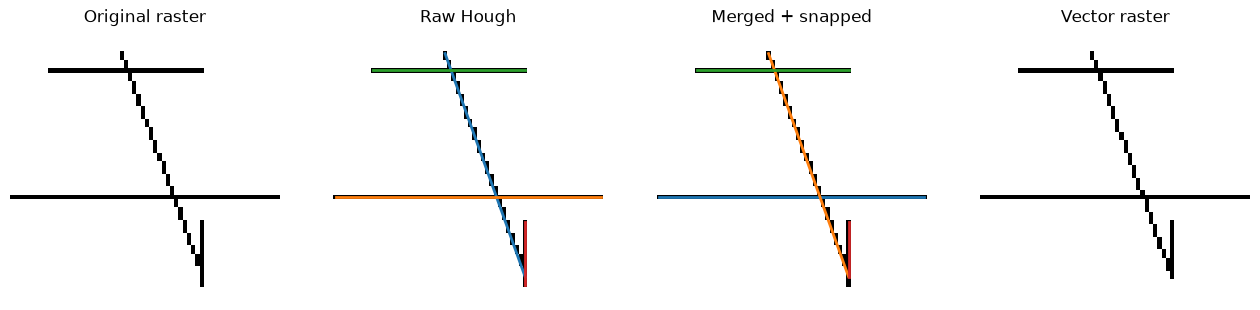

Example 1
True generated lines
  1: (4, 40) to (4, 61), angle=90.0°, length=21.0
  2: (1, 39) to (12, 7), angle=109.0°, length=33.8
  3: (15, 49) to (45, 49), angle=0.0°, length=30.0
  4: (15, 3) to (53, 3), angle=0.0°, length=38.0
  5: (39, 5) to (39, 32), angle=90.0°, length=27.0
Raw Hough lines
  1: (39, 3) to (39, 32), angle=90.0°, length=29.0
  2: (15, 49) to (45, 49), angle=0.0°, length=30.0
  3: (4, 40) to (4, 61), angle=90.0°, length=21.0
  4: (15, 3) to (53, 3), angle=0.0°, length=38.0
  5: (1, 39) to (12, 7), angle=109.0°, length=33.8
Final detected lines
  1: (13, 3) to (53, 3), angle=0.0°, length=40.0
  2: (1, 39) to (12, 7), angle=109.0°, length=33.8
  3: (15, 49) to (45, 49), angle=0.0°, length=30.0
  4: (39, 3) to (39, 32), angle=90.0°, length=29.0
  5: (4, 40) to (4, 61), angle=90.0°, length=21.0
Raster metrics: {'precision_tol': 0.9936, 'recall_tol': 1.0, 'f1_tol': 0.9968, 'strict_iou': 0.9682, 'true_pixels': 153, 'pred_pixels': 156}


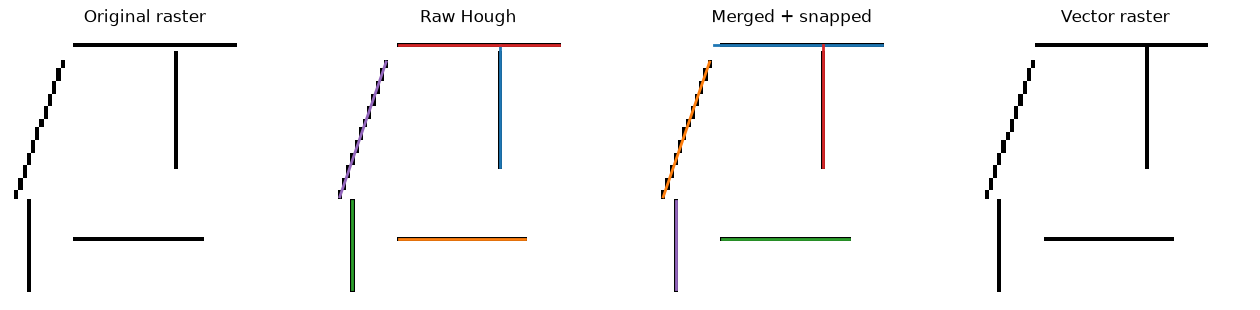

Example 2
True generated lines
  1: (1, 53) to (42, 53), angle=0.0°, length=41.0
  2: (31, 2) to (31, 20), angle=90.0°, length=18.0
  3: (32, 33) to (52, 22), angle=151.2°, length=22.8
  4: (58, 22) to (58, 55), angle=90.0°, length=33.0
Raw Hough lines
  1: (1, 53) to (42, 53), angle=0.0°, length=41.0
  2: (58, 22) to (58, 55), angle=90.0°, length=33.0
  3: (31, 2) to (31, 20), angle=90.0°, length=18.0
  4: (32, 33) to (52, 22), angle=151.2°, length=22.8
Final detected lines
  1: (1, 53) to (42, 53), angle=0.0°, length=41.0
  2: (58, 22) to (58, 55), angle=90.0°, length=33.0
  3: (32, 33) to (52, 22), angle=151.2°, length=22.8
  4: (31, 2) to (31, 20), angle=90.0°, length=18.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 1.0, 'f1_tol': 1.0, 'strict_iou': 0.9829, 'true_pixels': 116, 'pred_pixels': 116}


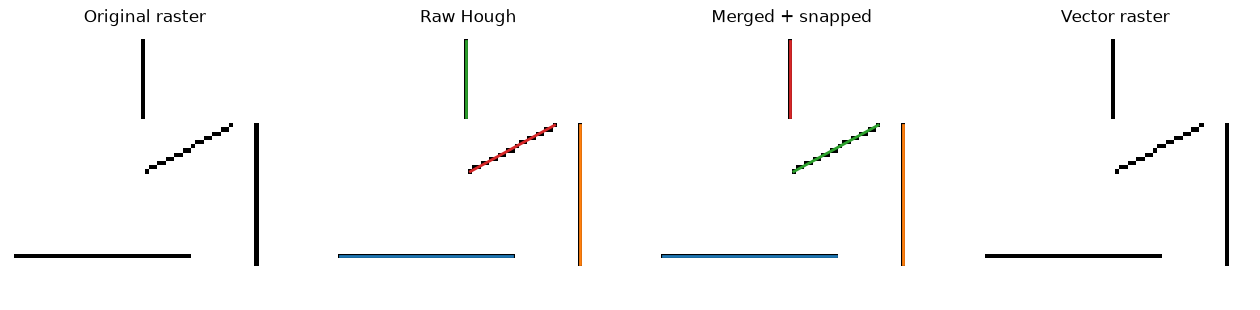

Example 3
True generated lines
  1: (1, 7) to (1, 34), angle=90.0°, length=27.0
  2: (1, 27) to (21, 27), angle=0.0°, length=20.0
  3: (13, 17) to (42, 17), angle=0.0°, length=29.0
  4: (17, 62) to (52, 1), angle=119.8°, length=70.3
Raw Hough lines
  1: (17, 62) to (47, 9), angle=119.5°, length=60.9
  2: (1, 7) to (1, 34), angle=90.0°, length=27.0
  3: (23, 17) to (43, 17), angle=0.0°, length=20.0
  4: (2, 27) to (21, 27), angle=0.0°, length=19.0
  5: (44, 15) to (51, 2), angle=118.3°, length=14.8
Final detected lines
  1: (17, 62) to (51, 2), angle=119.5°, length=69.0
  2: (1, 7) to (1, 34), angle=90.0°, length=27.0
  3: (1, 27) to (21, 27), angle=0.0°, length=20.0
  4: (23, 17) to (42, 17), angle=0.0°, length=19.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 0.9357, 'f1_tol': 0.9668, 'strict_iou': 0.7697, 'true_pixels': 140, 'pred_pixels': 129}


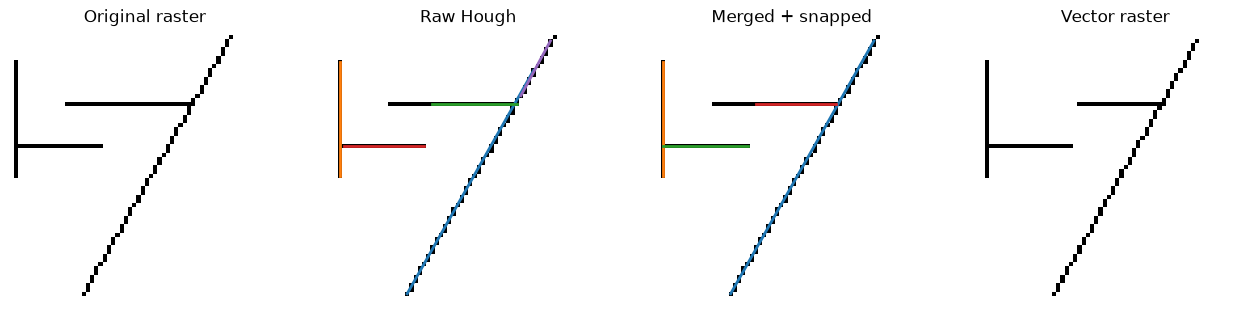

Example 4
True generated lines
  1: (4, 45) to (24, 11), angle=120.5°, length=39.4
  2: (18, 6) to (31, 18), angle=42.7°, length=17.7
  3: (9, 13) to (58, 61), angle=44.4°, length=68.6
Raw Hough lines
  1: (4, 45) to (23, 11), angle=119.2°, length=38.9
  2: (18, 22) to (47, 50), angle=44.0°, length=40.3
  3: (18, 6) to (30, 17), angle=42.5°, length=16.3
Final detected lines
  1: (17, 21) to (47, 50), angle=44.0°, length=41.7
  2: (4, 45) to (23, 11), angle=119.2°, length=38.9
  3: (18, 6) to (30, 17), angle=42.5°, length=16.3
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 0.8265, 'f1_tol': 0.905, 'strict_iou': 0.5351, 'true_pixels': 98, 'pred_pixels': 77}


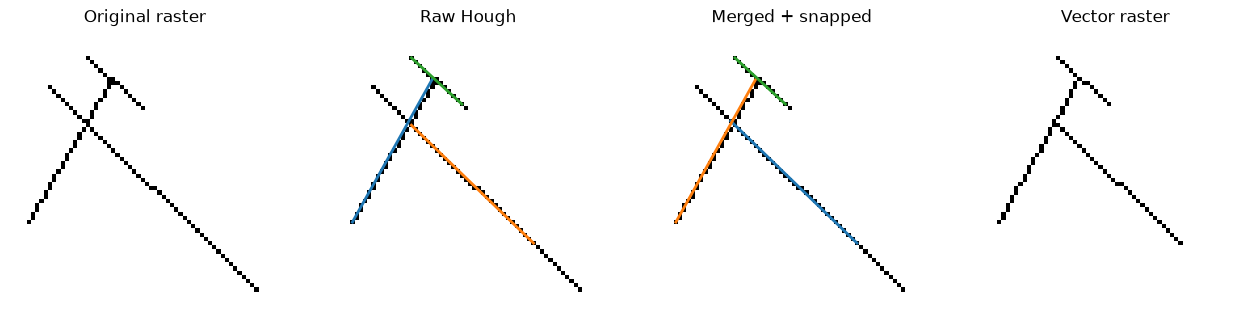

Example 5
True generated lines
  1: (53, 1) to (53, 63), angle=90.0°, length=62.0
Raw Hough lines
  1: (53, 1) to (53, 63), angle=90.0°, length=62.0
Final detected lines
  1: (53, 1) to (53, 63), angle=90.0°, length=62.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 1.0, 'f1_tol': 1.0, 'strict_iou': 1.0, 'true_pixels': 63, 'pred_pixels': 63}


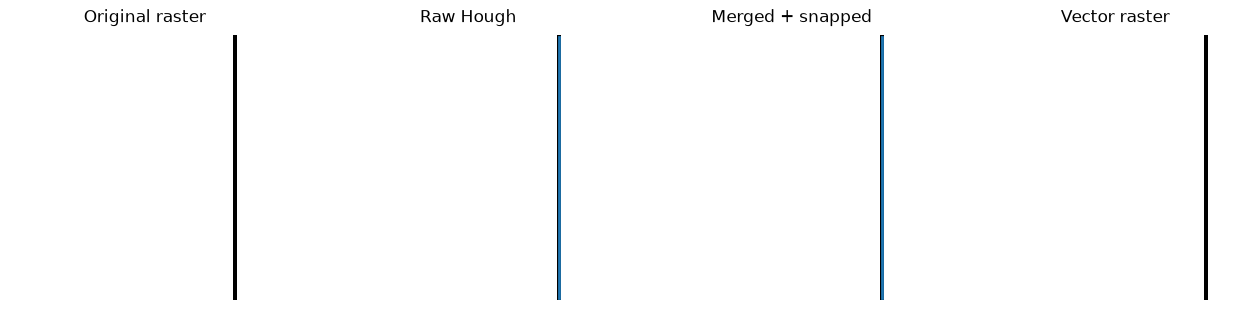

Example 6
True generated lines
  1: (2, 3) to (2, 37), angle=90.0°, length=34.0
  2: (6, 32) to (50, 32), angle=0.0°, length=44.0
  3: (11, 8) to (53, 32), angle=29.7°, length=48.4
Raw Hough lines
  1: (6, 32) to (53, 32), angle=0.0°, length=47.0
  2: (2, 3) to (2, 37), angle=90.0°, length=34.0
  3: (11, 8) to (52, 31), angle=29.3°, length=47.0
Final detected lines
  1: (2, 32) to (54, 32), angle=0.0°, length=52.0
  2: (11, 8) to (54, 32), angle=29.2°, length=49.2
  3: (2, 3) to (2, 37), angle=90.0°, length=34.0
Raster metrics: {'precision_tol': 0.9923, 'recall_tol': 1.0, 'f1_tol': 0.9961, 'strict_iou': 0.7943, 'true_pixels': 123, 'pred_pixels': 130}


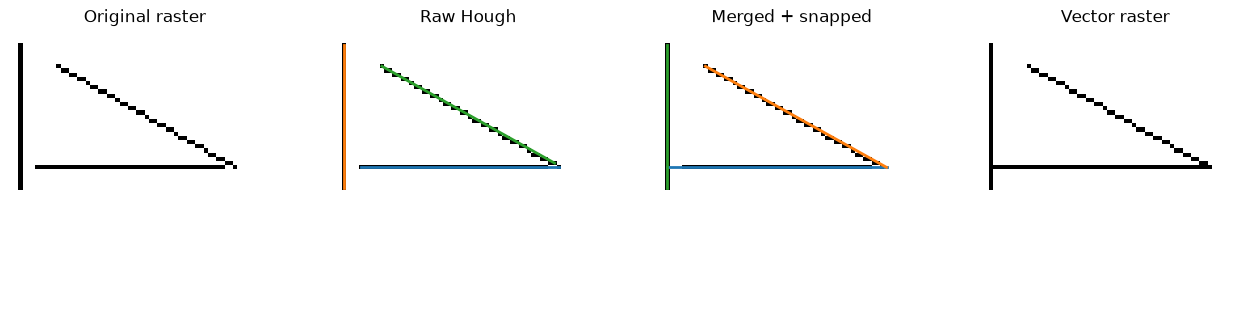

Example 7
True generated lines
  1: (17, 3) to (17, 61), angle=90.0°, length=58.0
  2: (6, 59) to (33, 59), angle=0.0°, length=27.0
  3: (20, 1) to (20, 58), angle=90.0°, length=57.0
  4: (10, 10) to (40, 10), angle=0.0°, length=30.0
  5: (25, 10) to (34, 26), angle=60.6°, length=18.4
Raw Hough lines
  1: (20, 1) to (20, 59), angle=90.0°, length=58.0
  2: (17, 3) to (17, 61), angle=90.0°, length=58.0
  3: (10, 10) to (40, 10), angle=0.0°, length=30.0
  4: (6, 59) to (33, 59), angle=0.0°, length=27.0
  5: (26, 11) to (34, 26), angle=61.9°, length=17.0
Final detected lines
  1: (20, 1) to (20, 59), angle=90.0°, length=58.0
  2: (17, 3) to (17, 59), angle=90.0°, length=56.0
  3: (10, 10) to (40, 10), angle=0.0°, length=30.0
  4: (6, 59) to (33, 59), angle=0.0°, length=27.0
  5: (25, 10) to (34, 26), angle=60.6°, length=18.4
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 0.9947, 'f1_tol': 0.9973, 'strict_iou': 0.9894, 'true_pixels': 189, 'pred_pixels': 187}


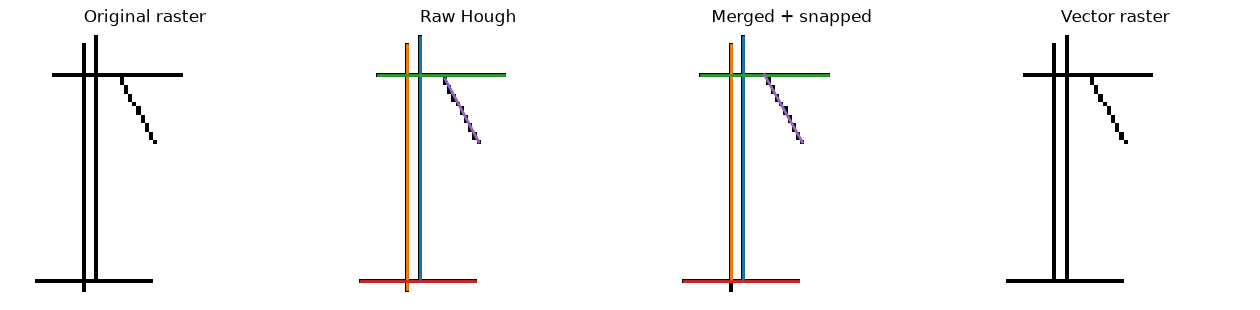

Example 8
True generated lines
  1: (8, 13) to (8, 37), angle=90.0°, length=24.0
  2: (9, 44) to (34, 44), angle=0.0°, length=25.0
  3: (23, 33) to (45, 20), angle=149.4°, length=25.6
Raw Hough lines
  1: (24, 32) to (45, 20), angle=150.3°, length=24.2
  2: (9, 44) to (34, 44), angle=0.0°, length=25.0
  3: (8, 13) to (8, 37), angle=90.0°, length=24.0
Final detected lines
  1: (9, 44) to (34, 44), angle=0.0°, length=25.0
  2: (24, 32) to (45, 20), angle=150.3°, length=24.2
  3: (8, 13) to (8, 37), angle=90.0°, length=24.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 1.0, 'f1_tol': 1.0, 'strict_iou': 0.8608, 'true_pixels': 74, 'pred_pixels': 73}


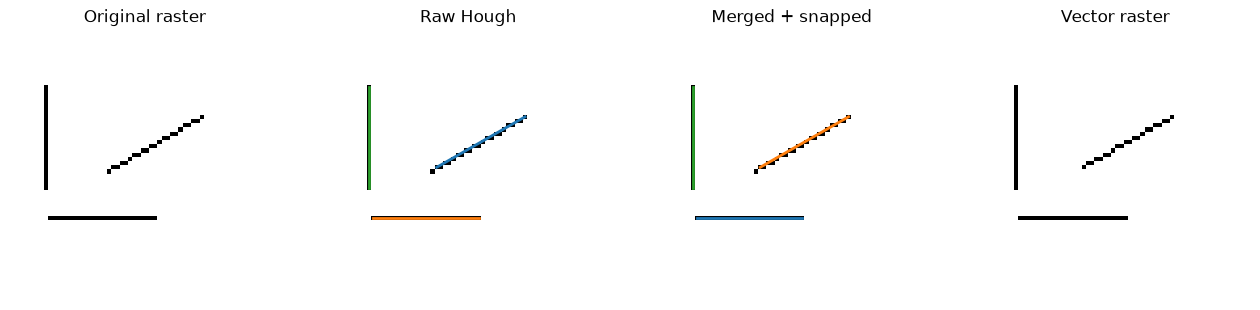

Example 9
True generated lines
  1: (1, 38) to (28, 38), angle=0.0°, length=27.0
  2: (18, 44) to (18, 59), angle=90.0°, length=15.0
  3: (21, 62) to (41, 62), angle=0.0°, length=20.0
Raw Hough lines
  1: (1, 38) to (28, 38), angle=0.0°, length=27.0
  2: (21, 62) to (41, 62), angle=0.0°, length=20.0
  3: (18, 44) to (18, 59), angle=90.0°, length=15.0
Final detected lines
  1: (1, 38) to (28, 38), angle=0.0°, length=27.0
  2: (18, 62) to (41, 62), angle=0.0°, length=23.0
  3: (18, 44) to (18, 62), angle=90.0°, length=18.0
Raster metrics: {'precision_tol': 0.9571, 'recall_tol': 1.0, 'f1_tol': 0.9781, 'strict_iou': 0.9286, 'true_pixels': 65, 'pred_pixels': 70}


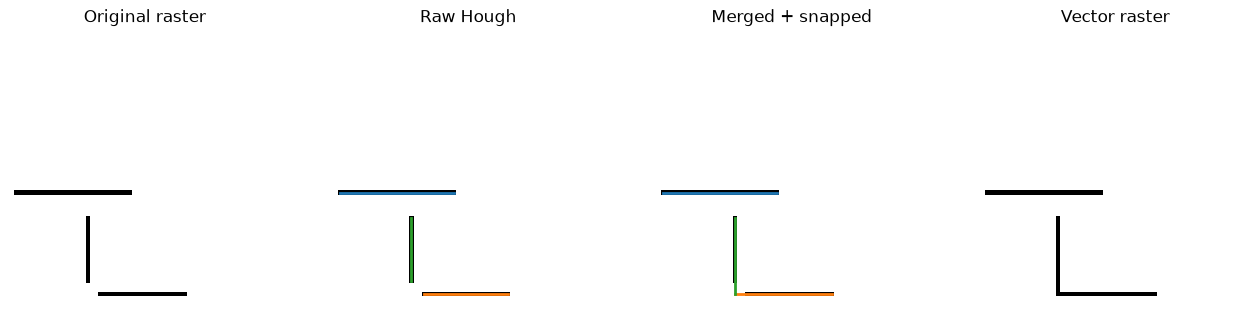

In [28]:
for sample_index in range(10):
    show_vectorisation_result(sample_index=sample_index, params=DEFAULT_PARAMS)


## Parameter search

This searches Hough settings against raster similarity. Start here if the results are poor.


In [29]:
def evaluate_params(params, images, max_samples=100, tolerance=1):
    scores = []
    n_samples = min(max_samples, len(images))

    for sample_index in range(n_samples):
        image = images[sample_index]
        detected_lines = vectorise_image(image, img_size=IMG_SIZE, params=params, return_stages=False)
        predicted_raster = rasterise_lines(detected_lines, img_size=IMG_SIZE, line_width=LINE_WIDTH)
        metrics = raster_similarity_metrics(image, predicted_raster, tolerance=tolerance)
        metrics["line_count"] = len(detected_lines)
        scores.append(metrics)

    df = pd.DataFrame(scores)

    return {
        "mean_precision_tol": df["precision_tol"].mean(),
        "mean_recall_tol": df["recall_tol"].mean(),
        "mean_f1_tol": df["f1_tol"].mean(),
        "mean_strict_iou": df["strict_iou"].mean(),
        "mean_line_count": df["line_count"].mean(),
    }


def grid_search_hough(images, max_samples=150):
    rows = []

    for threshold in [6, 8, 10, 12, 15, 18, 22]:
        for min_line_length in [6, 8, 10, 12, 16]:
            for max_line_gap in [1, 2, 3, 5, 8]:
                params = dict(DEFAULT_PARAMS)
                params.update({
                    "threshold": threshold,
                    "min_line_length": min_line_length,
                    "max_line_gap": max_line_gap,
                })

                result = evaluate_params(params, images, max_samples=max_samples, tolerance=1)

                rows.append({
                    "threshold": threshold,
                    "min_line_length": min_line_length,
                    "max_line_gap": max_line_gap,
                    **result
                })

    results_df = pd.DataFrame(rows)
    results_df = results_df.sort_values("mean_f1_tol", ascending=False).reset_index(drop=True)
    return results_df


search_results = grid_search_hough(X_test, max_samples=150)
search_results.head(15)


,threshold,min_line_length,max_line_gap,mean_precision_tol,mean_recall_tol,mean_f1_tol,mean_strict_iou,mean_line_count
0,8,6,8,0.997860,0.989971,0.993757,0.936164,2.980000
1,8,6,5,0.998646,0.988822,0.993567,0.938849,3.000000
2,8,6,3,0.998831,0.988509,0.993501,0.938343,3.026667
3,8,6,2,0.998966,0.987628,0.993116,0.939223,3.046667
4,8,8,8,0.997724,0.986664,0.991921,0.933837,2.960000
5,8,8,5,0.998646,0.985446,0.991756,0.935683,2.980000
6,8,8,3,0.998831,0.985134,0.991690,0.935177,3.006667
7,8,8,2,0.998966,0.984579,0.991479,0.936145,3.020000
8,8,6,1,0.998965,0.983931,0.991176,0.937990,3.046667
9,10,6,5,0.998537,0.983934,0.990922,0.935666,2.980000


## Use the best searched parameters

BEST_PARAMS:
{'threshold': 8, 'min_line_length': 6, 'max_line_gap': 8, 'angle_step': 1, 'merge_angle_tolerance': 3.0, 'merge_distance_tolerance': 1.5, 'merge_max_gap': 5.0, 'intersection_snap_distance': 4.0, 'segment_extent_tolerance': 4.0}
Example 0
True generated lines
  1: (9, 9) to (45, 9), angle=0.0°, length=36.0
  2: (0, 39) to (63, 39), angle=0.0°, length=63.0
  3: (26, 5) to (45, 57), angle=69.9°, length=55.4
  4: (45, 45) to (45, 60), angle=90.0°, length=15.0
Raw Hough lines
  1: (26, 5) to (45, 58), angle=70.3°, length=56.3
  2: (0, 39) to (63, 39), angle=0.0°, length=63.0
  3: (9, 9) to (45, 9), angle=0.0°, length=36.0
  4: (45, 45) to (45, 60), angle=90.0°, length=15.0
Final detected lines
  1: (0, 39) to (63, 39), angle=0.0°, length=63.0
  2: (26, 5) to (45, 58), angle=70.3°, length=56.3
  3: (9, 9) to (45, 9), angle=0.0°, length=36.0
  4: (45, 45) to (45, 58), angle=90.0°, length=13.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 0.994, 'f1_tol': 0.997, 'strict_iou

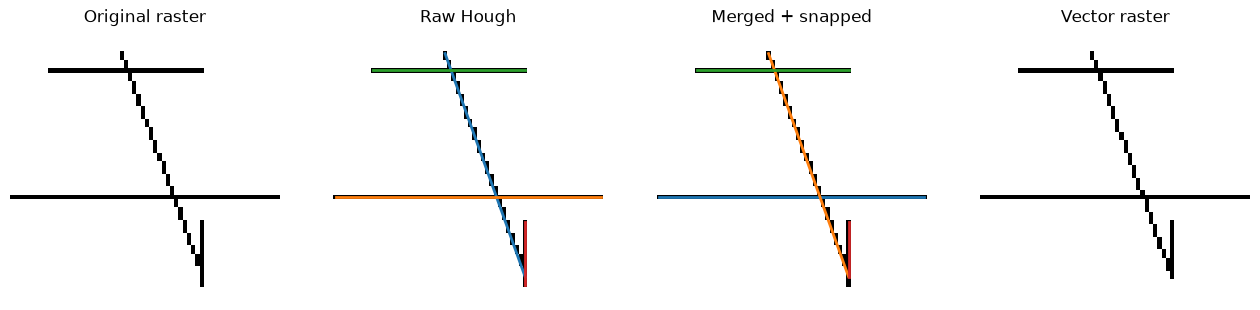

Example 1
True generated lines
  1: (4, 40) to (4, 61), angle=90.0°, length=21.0
  2: (1, 39) to (12, 7), angle=109.0°, length=33.8
  3: (15, 49) to (45, 49), angle=0.0°, length=30.0
  4: (15, 3) to (53, 3), angle=0.0°, length=38.0
  5: (39, 5) to (39, 32), angle=90.0°, length=27.0
Raw Hough lines
  1: (39, 3) to (39, 32), angle=90.0°, length=29.0
  2: (4, 29) to (4, 61), angle=90.0°, length=32.0
  3: (15, 49) to (45, 49), angle=0.0°, length=30.0
  4: (15, 3) to (53, 3), angle=0.0°, length=38.0
  5: (1, 39) to (12, 7), angle=109.0°, length=33.8
Final detected lines
  1: (13, 3) to (53, 3), angle=0.0°, length=40.0
  2: (1, 39) to (12, 7), angle=109.0°, length=33.8
  3: (4, 30) to (4, 61), angle=90.0°, length=31.0
  4: (15, 49) to (45, 49), angle=0.0°, length=30.0
  5: (39, 3) to (39, 32), angle=90.0°, length=29.0
Raster metrics: {'precision_tol': 0.9756, 'recall_tol': 1.0, 'f1_tol': 0.9877, 'strict_iou': 0.9212, 'true_pixels': 153, 'pred_pixels': 164}


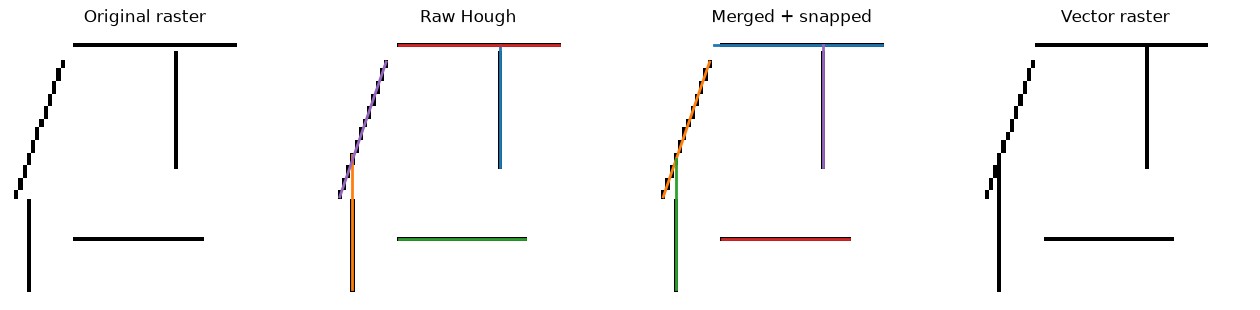

Example 2
True generated lines
  1: (1, 53) to (42, 53), angle=0.0°, length=41.0
  2: (31, 2) to (31, 20), angle=90.0°, length=18.0
  3: (32, 33) to (52, 22), angle=151.2°, length=22.8
  4: (58, 22) to (58, 55), angle=90.0°, length=33.0
Raw Hough lines
  1: (58, 22) to (58, 55), angle=90.0°, length=33.0
  2: (1, 53) to (42, 53), angle=0.0°, length=41.0
  3: (31, 2) to (31, 20), angle=90.0°, length=18.0
  4: (32, 33) to (52, 22), angle=151.2°, length=22.8
Final detected lines
  1: (1, 53) to (42, 53), angle=0.0°, length=41.0
  2: (58, 22) to (58, 55), angle=90.0°, length=33.0
  3: (32, 33) to (52, 22), angle=151.2°, length=22.8
  4: (31, 2) to (31, 20), angle=90.0°, length=18.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 1.0, 'f1_tol': 1.0, 'strict_iou': 0.9829, 'true_pixels': 116, 'pred_pixels': 116}


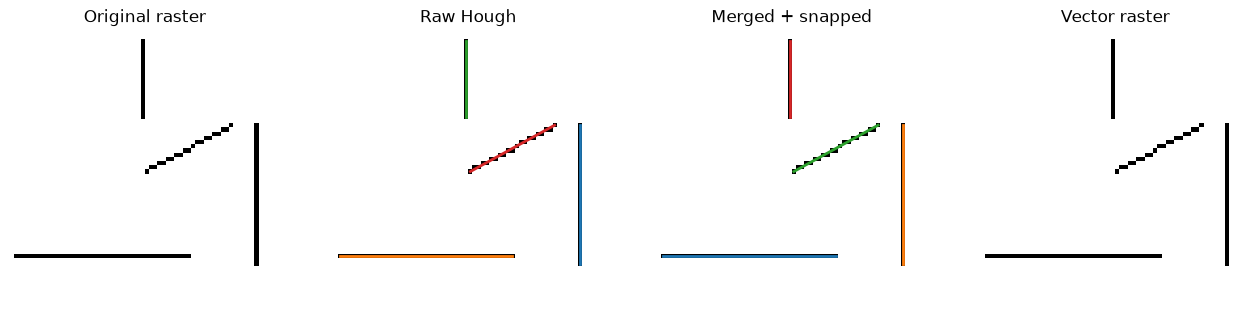

Example 3
True generated lines
  1: (1, 7) to (1, 34), angle=90.0°, length=27.0
  2: (1, 27) to (21, 27), angle=0.0°, length=20.0
  3: (13, 17) to (42, 17), angle=0.0°, length=29.0
  4: (17, 62) to (52, 1), angle=119.8°, length=70.3
Raw Hough lines
  1: (17, 62) to (42, 17), angle=119.1°, length=51.5
  2: (18, 61) to (52, 1), angle=119.5°, length=69.0
  3: (1, 7) to (1, 34), angle=90.0°, length=27.0
  4: (25, 17) to (41, 17), angle=0.0°, length=16.0
  5: (2, 27) to (21, 27), angle=0.0°, length=19.0
  6: (13, 17) to (22, 17), angle=0.0°, length=9.0
Final detected lines
  1: (17, 62) to (52, 1), angle=119.8°, length=70.3
  2: (13, 17) to (43, 17), angle=0.0°, length=30.0
  3: (1, 7) to (1, 34), angle=90.0°, length=27.0
  4: (1, 27) to (21, 27), angle=0.0°, length=20.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 1.0, 'f1_tol': 1.0, 'strict_iou': 1.0, 'true_pixels': 140, 'pred_pixels': 140}


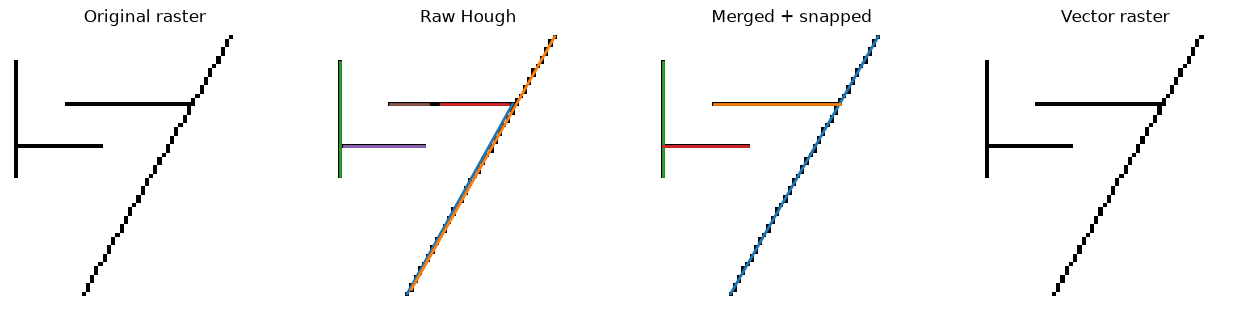

Example 4
True generated lines
  1: (4, 45) to (24, 11), angle=120.5°, length=39.4
  2: (18, 6) to (31, 18), angle=42.7°, length=17.7
  3: (9, 13) to (58, 61), angle=44.4°, length=68.6
Raw Hough lines
  1: (5, 44) to (24, 11), angle=119.9°, length=38.1
  2: (21, 25) to (50, 53), angle=44.0°, length=40.3
  3: (18, 6) to (31, 18), angle=42.7°, length=17.7
  4: (51, 54) to (58, 61), angle=45.0°, length=9.9
  5: (4, 45) to (20, 17), angle=119.7°, length=32.2
  6: (9, 13) to (16, 20), angle=45.0°, length=9.9
Final detected lines
  1: (9, 13) to (58, 61), angle=44.4°, length=68.6
  2: (4, 45) to (24, 11), angle=120.5°, length=39.4
  3: (18, 6) to (31, 18), angle=42.7°, length=17.7
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 1.0, 'f1_tol': 1.0, 'strict_iou': 1.0, 'true_pixels': 98, 'pred_pixels': 98}


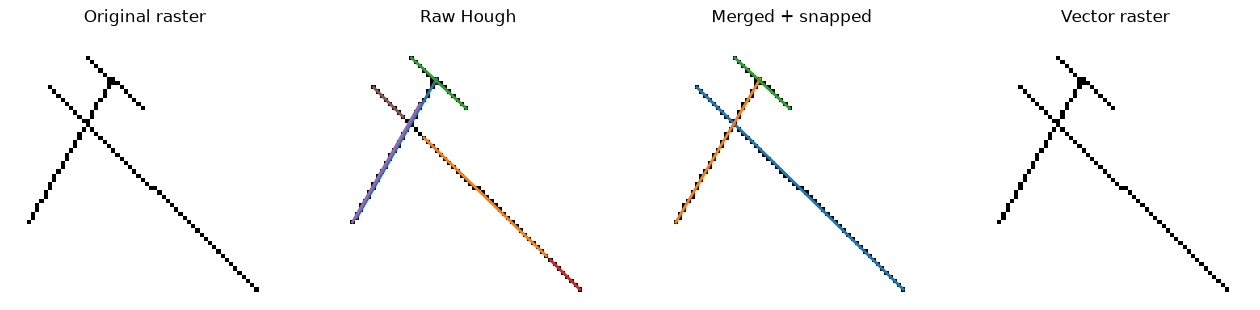

Example 5
True generated lines
  1: (53, 1) to (53, 63), angle=90.0°, length=62.0
Raw Hough lines
  1: (53, 1) to (53, 63), angle=90.0°, length=62.0
Final detected lines
  1: (53, 1) to (53, 63), angle=90.0°, length=62.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 1.0, 'f1_tol': 1.0, 'strict_iou': 1.0, 'true_pixels': 63, 'pred_pixels': 63}


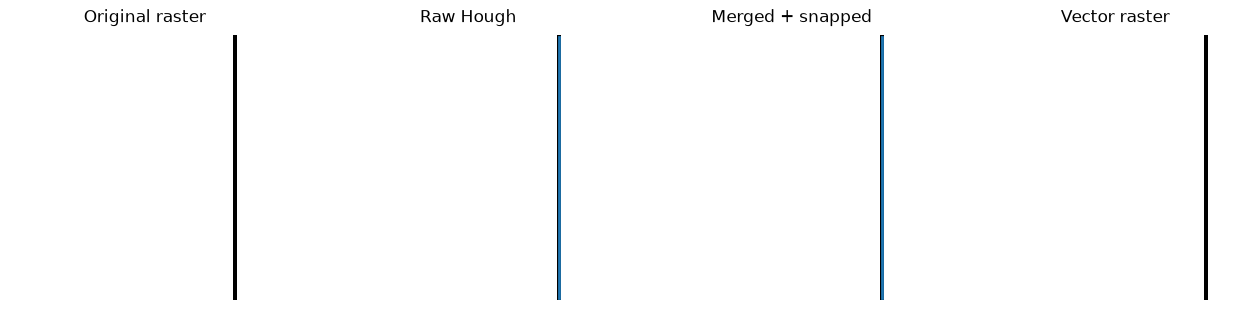

Example 6
True generated lines
  1: (2, 3) to (2, 37), angle=90.0°, length=34.0
  2: (6, 32) to (50, 32), angle=0.0°, length=44.0
  3: (11, 8) to (53, 32), angle=29.7°, length=48.4
Raw Hough lines
  1: (2, 32) to (53, 32), angle=0.0°, length=51.0
  2: (2, 3) to (2, 37), angle=90.0°, length=34.0
  3: (11, 8) to (52, 31), angle=29.3°, length=47.0
Final detected lines
  1: (2, 32) to (54, 32), angle=0.0°, length=52.0
  2: (11, 8) to (54, 32), angle=29.2°, length=49.2
  3: (2, 3) to (2, 37), angle=90.0°, length=34.0
Raster metrics: {'precision_tol': 0.9923, 'recall_tol': 1.0, 'f1_tol': 0.9961, 'strict_iou': 0.7943, 'true_pixels': 123, 'pred_pixels': 130}


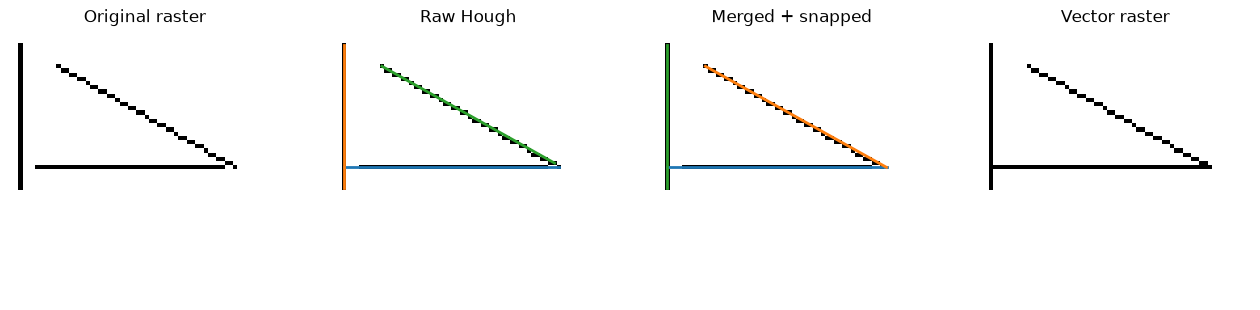

Example 7
True generated lines
  1: (17, 3) to (17, 61), angle=90.0°, length=58.0
  2: (6, 59) to (33, 59), angle=0.0°, length=27.0
  3: (20, 1) to (20, 58), angle=90.0°, length=57.0
  4: (10, 10) to (40, 10), angle=0.0°, length=30.0
  5: (25, 10) to (34, 26), angle=60.6°, length=18.4
Raw Hough lines
  1: (17, 11) to (40, 10), angle=177.5°, length=23.0
  2: (20, 1) to (20, 59), angle=90.0°, length=58.0
  3: (17, 3) to (17, 61), angle=90.0°, length=58.0
  4: (6, 59) to (33, 59), angle=0.0°, length=27.0
  5: (11, 10) to (26, 11), angle=3.8°, length=15.0
  6: (26, 12) to (34, 26), angle=60.3°, length=16.1
Final detected lines
  1: (20, 1) to (20, 59), angle=90.0°, length=58.0
  2: (17, 3) to (17, 59), angle=90.0°, length=56.0
  3: (6, 59) to (33, 59), angle=0.0°, length=27.0
  4: (17, 11) to (40, 10), angle=177.5°, length=23.0
  5: (25, 11) to (34, 26), angle=59.0°, length=17.5
  6: (11, 10) to (25, 11), angle=4.1°, length=14.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 0.9947, 

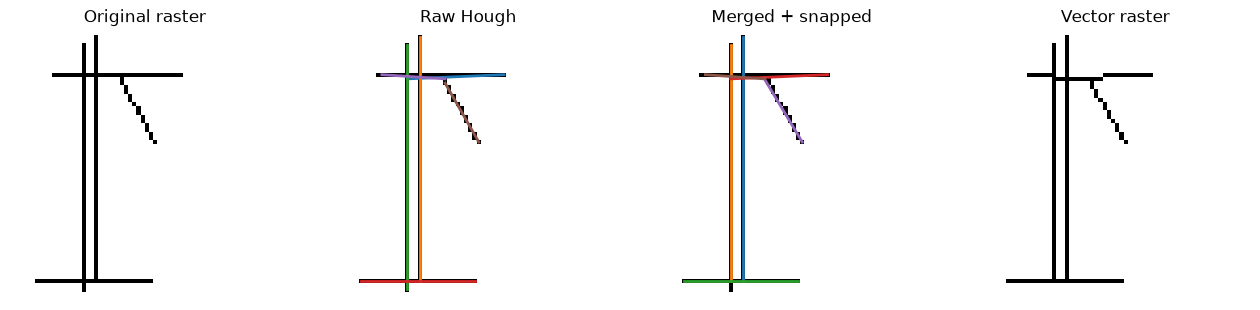

Example 8
True generated lines
  1: (8, 13) to (8, 37), angle=90.0°, length=24.0
  2: (9, 44) to (34, 44), angle=0.0°, length=25.0
  3: (23, 33) to (45, 20), angle=149.4°, length=25.6
Raw Hough lines
  1: (9, 44) to (34, 44), angle=0.0°, length=25.0
  2: (23, 33) to (45, 20), angle=149.4°, length=25.6
  3: (8, 13) to (8, 37), angle=90.0°, length=24.0
Final detected lines
  1: (23, 33) to (45, 20), angle=149.4°, length=25.6
  2: (9, 44) to (34, 44), angle=0.0°, length=25.0
  3: (8, 13) to (8, 37), angle=90.0°, length=24.0
Raster metrics: {'precision_tol': 1.0, 'recall_tol': 1.0, 'f1_tol': 1.0, 'strict_iou': 0.9733, 'true_pixels': 74, 'pred_pixels': 74}


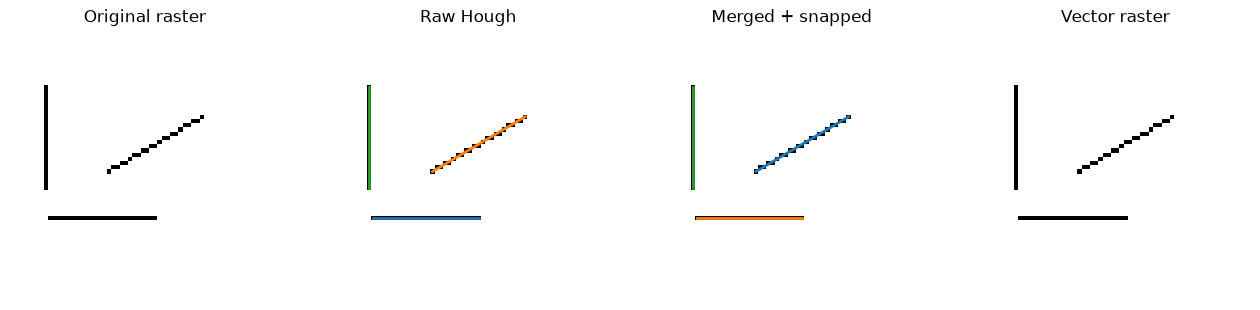

Example 9
True generated lines
  1: (1, 38) to (28, 38), angle=0.0°, length=27.0
  2: (18, 44) to (18, 59), angle=90.0°, length=15.0
  3: (21, 62) to (41, 62), angle=0.0°, length=20.0
Raw Hough lines
  1: (1, 38) to (28, 38), angle=0.0°, length=27.0
  2: (21, 62) to (41, 62), angle=0.0°, length=20.0
  3: (18, 44) to (18, 59), angle=90.0°, length=15.0
Final detected lines
  1: (1, 38) to (28, 38), angle=0.0°, length=27.0
  2: (18, 62) to (41, 62), angle=0.0°, length=23.0
  3: (18, 44) to (18, 62), angle=90.0°, length=18.0
Raster metrics: {'precision_tol': 0.9571, 'recall_tol': 1.0, 'f1_tol': 0.9781, 'strict_iou': 0.9286, 'true_pixels': 65, 'pred_pixels': 70}


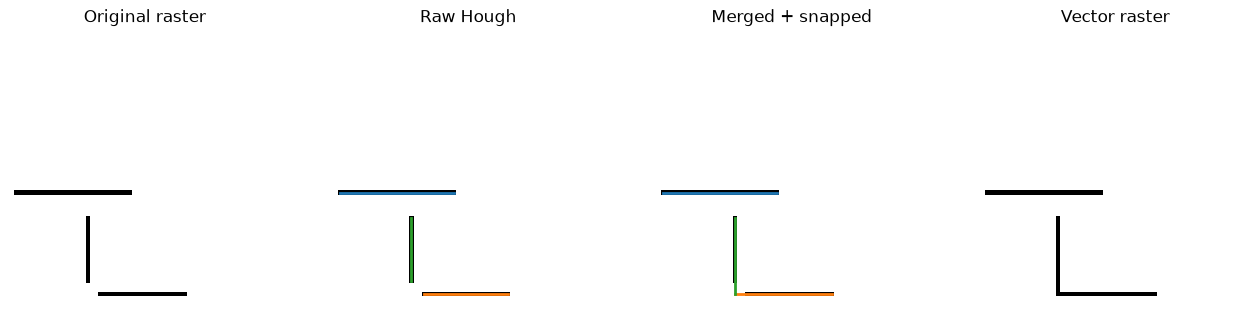

In [30]:
best_row = search_results.iloc[0]

BEST_PARAMS = dict(DEFAULT_PARAMS)
BEST_PARAMS.update({
    "threshold": int(best_row["threshold"]),
    "min_line_length": int(best_row["min_line_length"]),
    "max_line_gap": int(best_row["max_line_gap"]),
})

print("BEST_PARAMS:")
print(BEST_PARAMS)

for sample_index in range(10):
    show_vectorisation_result(sample_index=sample_index, params=BEST_PARAMS)


## Export detected lines as pseudo-labels

This creates endpoint labels from the classical detector. These labels can be used later to train a neural model to imitate the classical vectoriser.


In [31]:
def encode_lines_as_endpoint_vector(lines, img_size=64, max_lines=5):
    # Keep the longest lines if the detector finds more than MAX_LINES.
    lines = sorted(lines, key=lambda line: line_length(line), reverse=True)[:max_lines]

    # Then sort by centre to keep slots more stable.
    lines = sorted(
        lines,
        key=lambda line: (
            (line["x1"] + line["x2"]) / 2,
            (line["y1"] + line["y2"]) / 2,
        )
    )

    label_values = []

    for line in lines:
        label_values.extend([
            line["x1"] / (img_size - 1),
            line["y1"] / (img_size - 1),
            line["x2"] / (img_size - 1),
            line["y2"] / (img_size - 1),
            1.0
        ])

    while len(label_values) < max_lines * VALUES_PER_LINE:
        label_values.extend([0.0, 0.0, 0.0, 0.0, 0.0])

    return np.array(label_values, dtype="float32")


def create_hough_pseudo_labels(images, params=None):
    labels = []

    for image in images:
        lines = vectorise_image(image, img_size=IMG_SIZE, params=params, return_stages=False)
        label = encode_lines_as_endpoint_vector(lines, img_size=IMG_SIZE, max_lines=MAX_LINES)
        labels.append(label)

    return np.array(labels, dtype="float32")


y_test_hough = create_hough_pseudo_labels(X_test, params=BEST_PARAMS)

print("y_test_hough:", y_test_hough.shape)
print("First pseudo-label:")
print(np.round(y_test_hough[0], 3))


y_test_hough: (500, 25)
First pseudo-label:
[0.143 0.143 0.714 0.143 1.    0.    0.619 1.    0.619 1.    0.413 0.079
 0.714 0.921 1.    0.714 0.714 0.714 0.921 1.    0.    0.    0.    0.
 0.   ]


## Save pseudo-labels

In [32]:
np.savez_compressed(
    "hough_vectorised_test_data.npz",
    X_test=X_test,
    y_true=y_test,
    y_hough=y_test_hough
)

print("Saved: hough_vectorised_test_data.npz")


Saved: hough_vectorised_test_data.npz
